# 08 - GRDC Gauge Comparison

Load observed daily streamflow from the Global Runoff Data Center (GRDC) and compare with Google GRRR reanalysis and GloFAS data.

**Inputs (from Azure):**
- `ds-aa-nga-flooding/raw/grdc/GRDC-Daily.nc` — GRDC daily discharge
- `ds-aa-nga-flooding/raw/grdc/stationbasins.geojson` — GRDC station basins

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import io
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import ocha_stratus as stratus
import xarray as xr
from dotenv import load_dotenv

load_dotenv()

True

## Load data

In [11]:
# Load GRDC daily discharge NetCDF from Azure
container_client = stratus.get_container_client("projects", stage="dev")
nc_bytes = container_client.get_blob_client("ds-aa-nga-flooding/raw/grdc/GRDC-Daily.nc").download_blob().readall()

with tempfile.NamedTemporaryFile(suffix=".nc", delete=False) as tmp:
    tmp.write(nc_bytes)
    tmp_path = tmp.name

ds_grdc = xr.open_dataset(tmp_path)
ds_grdc

<xarray.Dataset> Size: 5MB
Dimensions:              (time: 24303, id: 54)
Coordinates:
  * time                 (time) datetime64[ns] 194kB 1958-06-19 ... 2024-12-31
  * id                   (id) int64 432B 1834010 1834015 ... 1837801 1837810
Data variables:
    runoff_mean          (time, id) float32 5MB ...
    area                 (id) float32 216B ...
    country              (id) <U2 432B ...
    geo_x                (id) float32 216B ...
    geo_y                (id) float32 216B ...
    geo_z                (id) float32 216B ...
    owneroforiginaldata  (id) <U42 9kB ...
    river_name           (id) <U15 3kB ...
    station_name         (id) <U28 6kB ...
    timezone             (id) float32 216B ...
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 11/03/2026
    missing_value:  -999.000

In [ ]:
# Load station basins GeoJSON from Azure
geojson_bytes = container_client.get_blob_client("ds-aa-nga-flooding/raw/grdc/stationbasins.geojson").download_blob().readall()
gdf_basins = gpd.read_file(io.BytesIO(geojson_bytes))
gdf_basins.head()

Station basins: 56 features
['grdc_no', 'river', 'station', 'area', 'altitude', 'lat_org', 'long_org', 'lat_pp', 'long_pp', 'dist_km', 'area_calc', 'quality', 'type', 'comment', 'source', 'geometry']


,grdc_no,river,station,area,altitude,lat_org,long_org,lat_pp,long_pp,dist_km,area_calc,quality,type,comment,source,geometry
0,1834010.0,SOKOTO,KENDE,-999.0,-999.0,11.5228,4.2506,11.5229,4.2479,0.3,181242.22,High,Manual,Station and river name could be identified,hydrosheds,"POLYGON ((8.1042 16.1458, 8.1417 16.1458, 8.14..."
1,1834015.0,RIVER NIGER,BARO,-999.0,-999.0,8.5830,6.3830,8.5979,6.4062,3.0,1734858.40,High,Manual,Station and river name could be identified,hydrosheds,"MULTIPOLYGON (((-0.8458 12.5833, -0.8417 12.58..."
2,1834020.0,RIVER NIGER,ONITSHA,-999.0,-999.0,6.1625,6.7755,6.1604,6.7688,0.8,2120215.67,High,Manual,Station and river name could be identified,hydrosheds,"MULTIPOLYGON (((-0.8458 12.5833, -0.8417 12.58..."
3,1834025.0,RIVER KADUNA,WUYA,-999.0,-999.0,9.1426,5.8337,9.1438,5.8354,0.2,64596.14,High,Manual,Station and river name could be identified,hydrosheds,"POLYGON ((6.9208 11.55, 6.95 11.55, 6.95 11.54..."
4,1834100.0,RIVER NIGER,JEBBA,-999.0,-999.0,9.1800,4.8200,9.1396,4.7979,5.1,1605091.60,Low,Manual,Stations were relocated manually,hydrosheds,"MULTIPOLYGON (((-0.8458 12.5833, -0.8417 12.58..."


## Map: GRDC gauge locations and basins

In [13]:
# Build point GeoDataFrame from dataset coordinates
import numpy as np

station_ids = ds_grdc["id"].values if "id" in ds_grdc else ds_grdc["station"].values
lons = ds_grdc["geo_x"].values  # longitude
lats = ds_grdc["geo_y"].values  # latitude

# Try to get station names if available
station_names = ds_grdc["station_name"].values if "station_name" in ds_grdc else station_ids

gdf_stations = gpd.GeoDataFrame(
    {"station_id": station_ids, "station_name": station_names},
    geometry=gpd.points_from_xy(lons, lats),
    crs="EPSG:4326",
)
print(f"Gauge stations: {len(gdf_stations)}")
gdf_stations

Gauge stations: 54


,station_id,station_name,geometry
0,1834010,KENDE,POINT (4.25057 11.52278)
1,1834015,BARO,POINT (6.383 8.583)
2,1834020,ONITSHA,POINT (6.77548 6.1625)
3,1834025,WUYA,POINT (5.83367 9.14257)
4,1834101,LOKOJA,POINT (6.7667 7.8)
5,1834110,YIDERE BODE,POINT (4.1333 11.3833)
6,1835010,WURO BOKI,POINT (12.79327 9.38439)
7,1835015,KATSINA ALA,POINT (9.28829 7.15102)
8,1835020,MAKURDI,POINT (8.53213 7.74618)
9,1835025,UMAISHA,POINT (7.18451 8.00275)


In [19]:
ds_grdc.to_dataframe()

runoff_mean    area country      geo_x      geo_y  geo_z  \
time       id                                                                  
1958-06-19 1834010          NaN  -999.0      NG   4.250571  11.522780 -999.0   
           1834015          NaN  -999.0      NG   6.383000   8.583000 -999.0   
           1834020          NaN  -999.0      NG   6.775478   6.162503 -999.0   
           1834025          NaN  -999.0      NG   5.833671   9.142568 -999.0   
           1834101          NaN  -999.0      NG   6.766700   7.800000 -999.0   
...                         ...     ...     ...        ...        ...    ...   
2024-12-31 1837700          NaN  -999.0      NG  13.166667  11.850000  322.0   
           1837701          NaN  -999.0      NG  13.313889  11.685000  329.0   
           1837800          NaN  4750.0      NG  13.683333  11.533333  328.0   
           1837801          NaN  -999.0      NG  13.230556  10.455556  488.0   
           1837810          NaN  -999.0      NG  14.116667  12.316667  289.0   

                                           owneroforiginaldata    river_name  \
time       id                                                                  
1958-06-19 1834010         Niger - Niger Basin Authority (NBA)        SOKOTO   
           1834015         Niger - Niger Basin Authority (NBA)   RIVER NIGER   
           1834020         Niger - Niger Basin Authority (NBA)   RIVER NIGER   
           1834025         Niger - Niger Basin Authority (NBA)  RIVER KADUNA   
           1834101         Niger - Niger Basin Authority (NBA)   RIVER NIGER   
...                                                        ...           ...   
2024-12-31 1837700  Niger - EU-IWRM Project for the Yobe basin   RIVER NGADA   
           1837701  Niger - EU-IWRM Project for the Yobe basin   RIVER NGADA   
           1837800  Niger - EU-IWRM Project for the Yobe basin      YEDSERAM   
           1837801  Niger - EU-IWRM Project for the Yobe basin      YEDSERAM   
           1837810  Niger - EU-IWRM Project for the Yobe basin         MBULI   

                   station_name  timezone  
time       id                              
1958-06-19 1834010        KENDE       1.0  
           1834015         BARO       1.0  
           1834020      ONITSHA       1.0  
           1834025         WUYA       1.0  
           1834101       LOKOJA       1.0  
...                         ...       ...  
2024-12-31 1837700    MAIDUGURI       1.0  
           1837701     LOGOJERI       1.0  
           1837800         BAMA       1.0  
           1837801          UBA       1.0  
           1837810        MBULI       1.0  

[1312362 rows x 10 columns]

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_26912/43695905.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


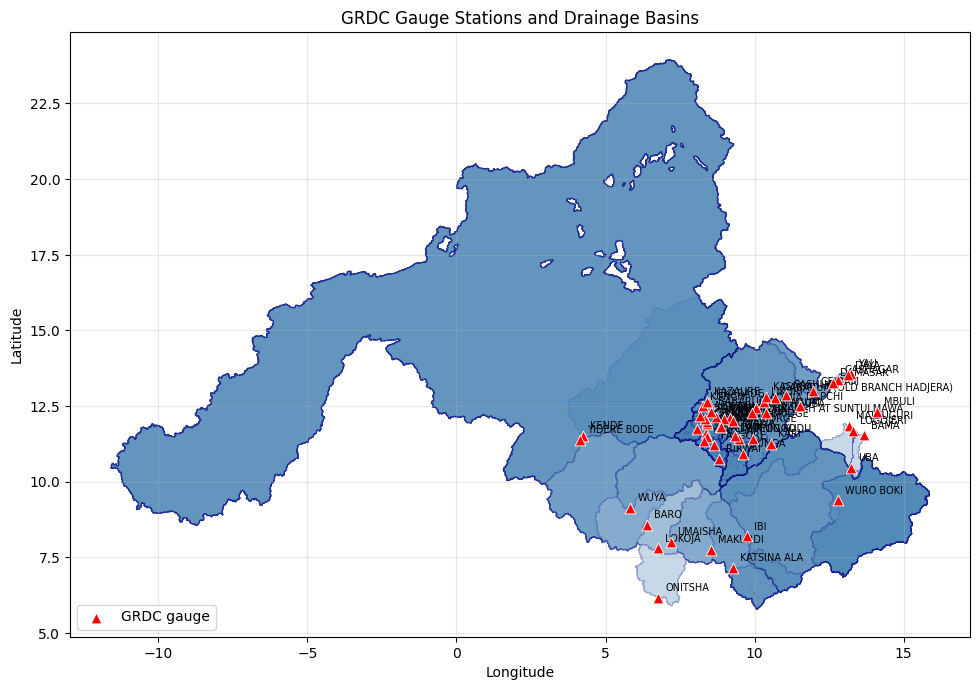

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

gdf_basins.plot(ax=ax, color="steelblue", edgecolor="navy", linewidth=0.8, alpha=0.3, label="Station basins")
gdf_stations.plot(ax=ax, color="red", markersize=60, marker="^", edgecolor="white", linewidth=0.6, zorder=5, label="GRDC gauge")

for _, row in gdf_stations.iterrows():
    ax.annotate(
        str(row["station_name"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_title("GRDC Gauge Stations and Drainage Basins")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
gauge_mapping = {
    # Makurdi
    1835020: "hybas_1120911340",
    # Umaisha
    1835025: "hybas_1120904190",
    # Lokoja
    1834101: "hybas_1120908000", # or maybe: hybas_1120909890
    # Kende
    1834010: "hybas_1120750570",
    # Yidere bode
    1834110: "hybas_1120755820",
    # Wuro boki
    1835010: "hybas_1121971560", # or maybe: hybas_1120842550
    # Ibi
    1835900: "hybas_1120887720",
    # Baro
    1834015: "hybas_1120870480",
    # Onitsha
    1834020: "hybas_1120975380" # not qa
}

## Correlation with Google GRRR Reanalysis

In [18]:
import numpy as np
import pandas as pd
from scipy import stats

from src.datasources import grrr

# Load Google GRRR reanalysis for all mapped gauges
google_gauge_ids = list(gauge_mapping.values())
ds_ra = grrr.load_reanalysis(gauge=google_gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["date"] = df_ra["valid_time"].dt.normalize()
print(f"Google reanalysis: {df_ra['date'].min().date()} – {df_ra['date'].max().date()}")
print(f"Gauges loaded: {df_ra['gauge_id'].nunique()}")

Google reanalysis: 1980-01-01 – 2023-12-23
Gauges loaded: 9


In [19]:
# Build GRDC daily timeseries in long format, masking -999 missing values
df_grdc = ds_grdc["runoff_mean"].to_dataframe().reset_index()
df_grdc = df_grdc.rename(columns={"time": "date", "id": "grdc_id", "runoff_mean": "grdc_q"})
df_grdc["grdc_q"] = df_grdc["grdc_q"].where(df_grdc["grdc_q"] > -900)
df_grdc["date"] = pd.to_datetime(df_grdc["date"]).dt.normalize()

name_lookup = gdf_stations.set_index("station_id")["station_name"].to_dict()

In [20]:
# Compute Spearman correlation for each GRDC–Google pair over the overlapping period
results = []
pair_data = {}

for grdc_id, google_id in gauge_mapping.items():
    station = name_lookup.get(grdc_id, str(grdc_id))

    grdc_ts = df_grdc[df_grdc["grdc_id"] == grdc_id][["date", "grdc_q"]].dropna()
    google_ts = df_ra[df_ra["gauge_id"] == google_id][["date", "streamflow"]].dropna()

    merged = grdc_ts.merge(google_ts, on="date", how="inner").sort_values("date").reset_index(drop=True)

    if len(merged) < 30:
        print(f"Skipping {station}: only {len(merged)} overlapping days")
        continue

    r, p = stats.spearmanr(merged["grdc_q"], merged["streamflow"])
    results.append({
        "station_name": station,
        "grdc_id": grdc_id,
        "google_id": google_id,
        "n_days": len(merged),
        "date_start": merged["date"].min().date(),
        "date_end": merged["date"].max().date(),
        "spearman_r": round(r, 3),
        "p_value": round(p, 4),
    })
    pair_data[grdc_id] = merged

df_corr = pd.DataFrame(results).sort_values("spearman_r", ascending=False).reset_index(drop=True)
df_corr

,station_name,grdc_id,google_id,n_days,date_start,date_end,spearman_r,p_value
0,IBI,1835900,hybas_1120887720,3653,1980-01-01,2002-10-30,0.892,0.0
1,MAKURDI,1835020,hybas_1120911340,6939,1990-01-01,2023-10-29,0.855,0.0
2,YIDERE BODE,1834110,hybas_1120755820,13268,1984-01-01,2023-12-23,0.855,0.0
3,KENDE,1834010,hybas_1120750570,6110,1990-04-02,2023-12-23,0.826,0.0
4,ONITSHA,1834020,hybas_1120975380,3128,1990-04-17,2017-12-03,0.750,0.0
5,UMAISHA,1835025,hybas_1120904190,3379,1990-01-01,2023-12-23,0.742,0.0
6,LOKOJA,1834101,hybas_1120908000,13893,1980-01-01,2023-12-23,0.694,0.0
7,WURO BOKI,1835010,hybas_1121971560,3722,1991-03-08,2023-12-23,0.545,0.0
8,BARO,1834015,hybas_1120870480,3751,1990-01-01,2023-02-09,0.516,0.0


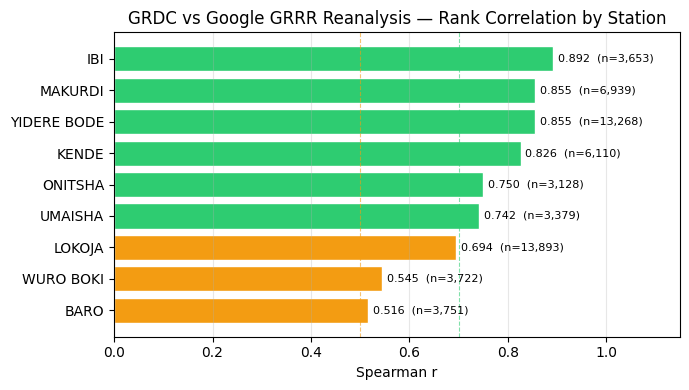

In [21]:
# Summary: horizontal bar chart of Spearman r by station
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#2ecc71" if r >= 0.7 else "#f39c12" if r >= 0.5 else "#e74c3c" for r in df_corr["spearman_r"]]
bars = ax.barh(df_corr["station_name"], df_corr["spearman_r"], color=colors, edgecolor="white")

for bar, r, n in zip(bars, df_corr["spearman_r"], df_corr["n_days"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{r:.3f}  (n={n:,})", va="center", fontsize=8)

ax.axvline(0.7, color="#2ecc71", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color="#f39c12", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Spearman r")
ax.set_title("GRDC vs Google GRRR Reanalysis — Rank Correlation by Station")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

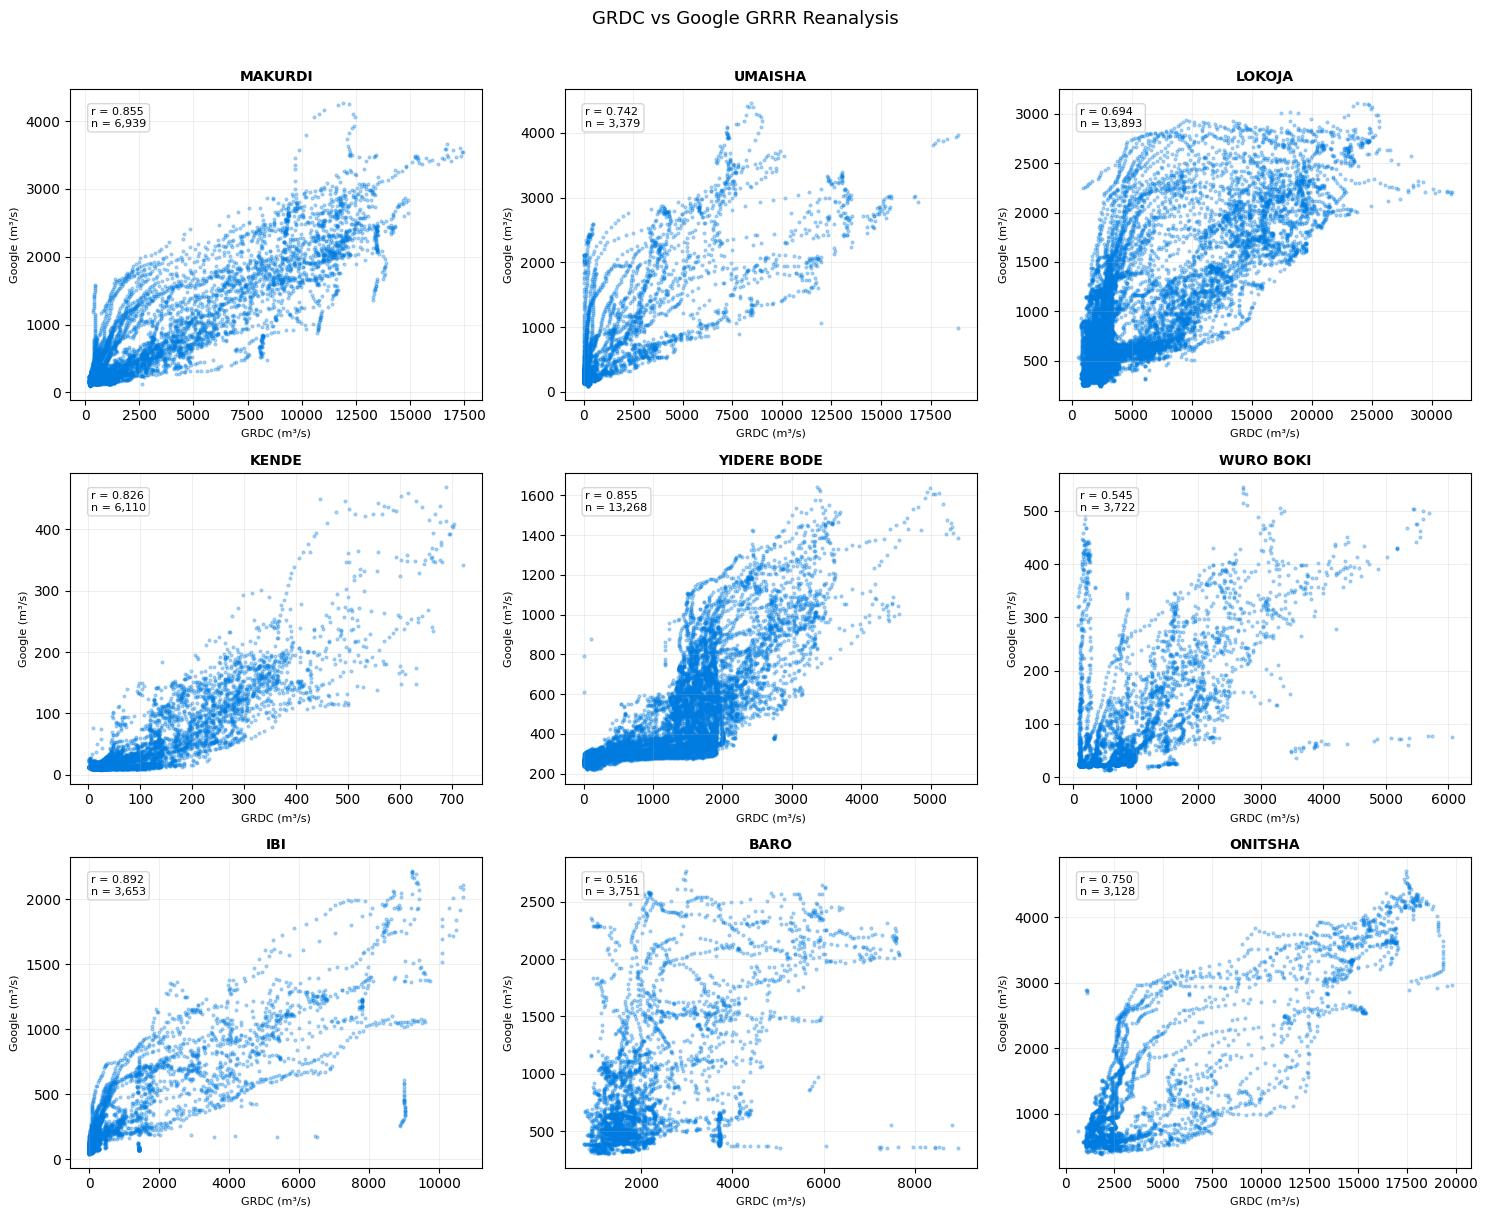

In [24]:
# 3×3 scatter plots of actual discharge values, annotated with Spearman r
n = len(pair_data)
ncols = 3
nrows = int(np.ceil(n / ncols))

ordered_grdc_ids = [gid for gid in gauge_mapping if gid in pair_data]

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, grdc_id in enumerate(ordered_grdc_ids):
    ax = axes[i]
    merged = pair_data[grdc_id]
    station = name_lookup.get(grdc_id, str(grdc_id))
    row = df_corr[df_corr["grdc_id"] == grdc_id].iloc[0]

    ax.scatter(merged["grdc_q"], merged["streamflow"], s=4, alpha=0.3, color="#007CE0", rasterized=True)

    ax.set_title(station, fontsize=10, fontweight="bold")
    ax.set_xlabel("GRDC (m³/s)", fontsize=8)
    ax.set_ylabel("Google (m³/s)", fontsize=8)
    ax.annotate(f"r = {row['spearman_r']:.3f}\nn = {row['n_days']:,}",
                xy=(0.05, 0.88), xycoords="axes fraction", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc", alpha=0.8))
    ax.grid(True, alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("GRDC vs Google GRRR Reanalysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/grdc_google_comparison.png", dpi=300)

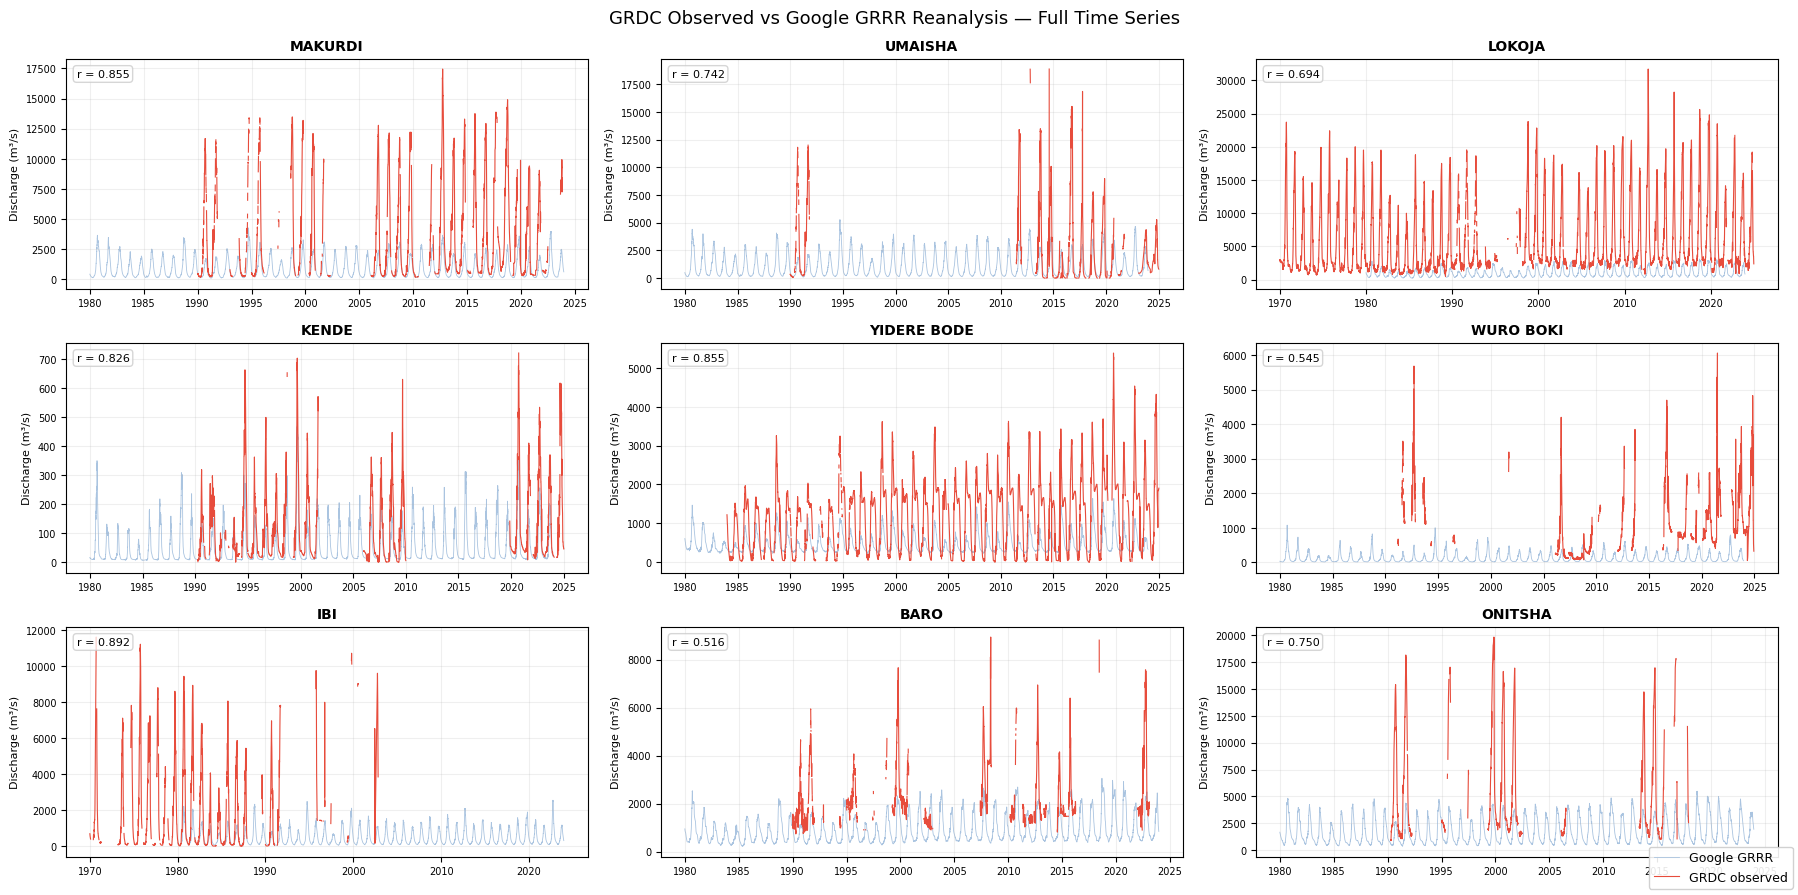

In [26]:
# Full time series for each GRDC gauge, overlaid with Google reanalysis
# Outer-join on date so GRDC gaps remain NaN — matplotlib leaves those blank in a line plot
ordered_grdc_ids = [gid for gid in gauge_mapping if gid in pair_data]

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows), sharex=False)
axes = axes.flatten()

for i, grdc_id in enumerate(ordered_grdc_ids):
    ax = axes[i]
    google_id = gauge_mapping[grdc_id]
    station = name_lookup.get(grdc_id, str(grdc_id))
    row = df_corr[df_corr["grdc_id"] == grdc_id].iloc[0]

    # Outer join so GRDC missing days stay as NaN (not dropped)
    grdc_ts = df_grdc[df_grdc["grdc_id"] == grdc_id][["date", "grdc_q"]]
    google_ts = df_ra[df_ra["gauge_id"] == google_id][["date", "streamflow"]]
    ts = google_ts.merge(grdc_ts, on="date", how="outer").sort_values("date")

    ax.plot(ts["date"], ts["streamflow"], color="#aac4e0", linewidth=0.6,
            label="Google GRRR", zorder=1)
    ax.plot(ts["date"], ts["grdc_q"], color="#e74c3c", linewidth=0.8,
            label="GRDC observed", zorder=2)

    ax.set_title(station, fontsize=10, fontweight="bold")
    ax.set_ylabel("Discharge (m³/s)", fontsize=8)
    ax.annotate(f"r = {row['spearman_r']:.3f}", xy=(0.02, 0.92), xycoords="axes fraction",
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc", alpha=0.8))
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=9, framealpha=0.9)

fig.suptitle("GRDC Observed vs Google GRRR Reanalysis — Full Time Series", fontsize=13)
plt.tight_layout()
plt.show()

## Peak event comparison

For each gauge pair, compute wet-season (Jul–Nov) annual maxima and empirical 1-in-3 and 1-in-5 year thresholds independently from each dataset. Then compare which years each flags as exceedance events.

In [27]:
WET_SEASON_MONTHS = [7, 8, 9, 10, 11]
MIN_WET_OBS = 30  # min GRDC wet-season obs to include a year
RETURN_PERIODS = [3, 5]

peak_data = {}

for grdc_id, google_id in gauge_mapping.items():
    if grdc_id not in pair_data:
        continue
    station = name_lookup.get(grdc_id, str(grdc_id))

    # GRDC: wet-season annual max across all available years
    grdc_ws = df_grdc[
        (df_grdc["grdc_id"] == grdc_id) &
        (df_grdc["date"].dt.month.isin(WET_SEASON_MONTHS))
    ].copy()
    grdc_ws["year"] = grdc_ws["date"].dt.year
    grdc_ann = grdc_ws.groupby("year").agg(
        grdc_max=("grdc_q", "max"),
        n_obs=("grdc_q", "count"),
    ).reset_index()
    # Only keep years with enough valid observations
    grdc_ann = grdc_ann[grdc_ann["n_obs"] >= MIN_WET_OBS].dropna(subset=["grdc_max"])

    # Google: wet-season annual max across all available years
    google_ws = df_ra[
        (df_ra["gauge_id"] == google_id) &
        (df_ra["date"].dt.month.isin(WET_SEASON_MONTHS))
    ].copy()
    google_ws["year"] = google_ws["date"].dt.year
    google_ann = google_ws.groupby("year").agg(
        google_max=("streamflow", "max"),
    ).reset_index()

    # Empirical thresholds from each dataset's full record (before merging)
    thresholds = {}
    for rp in RETURN_PERIODS:
        q = 1 - 1 / rp
        thresholds[f"grdc_{rp}yr"] = grdc_ann["grdc_max"].quantile(q)
        thresholds[f"google_{rp}yr"] = google_ann["google_max"].quantile(q)

    # Inner join on year (need both to have data for fair comparison)
    ann = grdc_ann[["year", "grdc_max"]].merge(google_ann, on="year", how="inner")
    if len(ann) < 3:
        print(f"Skipping {station}: only {len(ann)} comparable years")
        continue

    for rp in RETURN_PERIODS:
        ann[f"grdc_exceed_{rp}yr"] = ann["grdc_max"] >= thresholds[f"grdc_{rp}yr"]
        ann[f"google_exceed_{rp}yr"] = ann["google_max"] >= thresholds[f"google_{rp}yr"]

    # Normalise to each dataset's own 1-in-3yr threshold so both plot on the same scale
    ann["grdc_norm"] = ann["grdc_max"] / thresholds["grdc_3yr"]
    ann["google_norm"] = ann["google_max"] / thresholds["google_3yr"]
    # 1-in-5yr normalised level (relative to 1-in-3yr)
    grdc_5yr_norm = thresholds["grdc_5yr"] / thresholds["grdc_3yr"]
    google_5yr_norm = thresholds["google_5yr"] / thresholds["google_3yr"]

    peak_data[grdc_id] = dict(
        station=station, ann=ann, thresholds=thresholds,
        grdc_5yr_norm=grdc_5yr_norm, google_5yr_norm=google_5yr_norm,
    )

print(f"Peak data computed for {len(peak_data)} stations")

Peak data computed for 9 stations


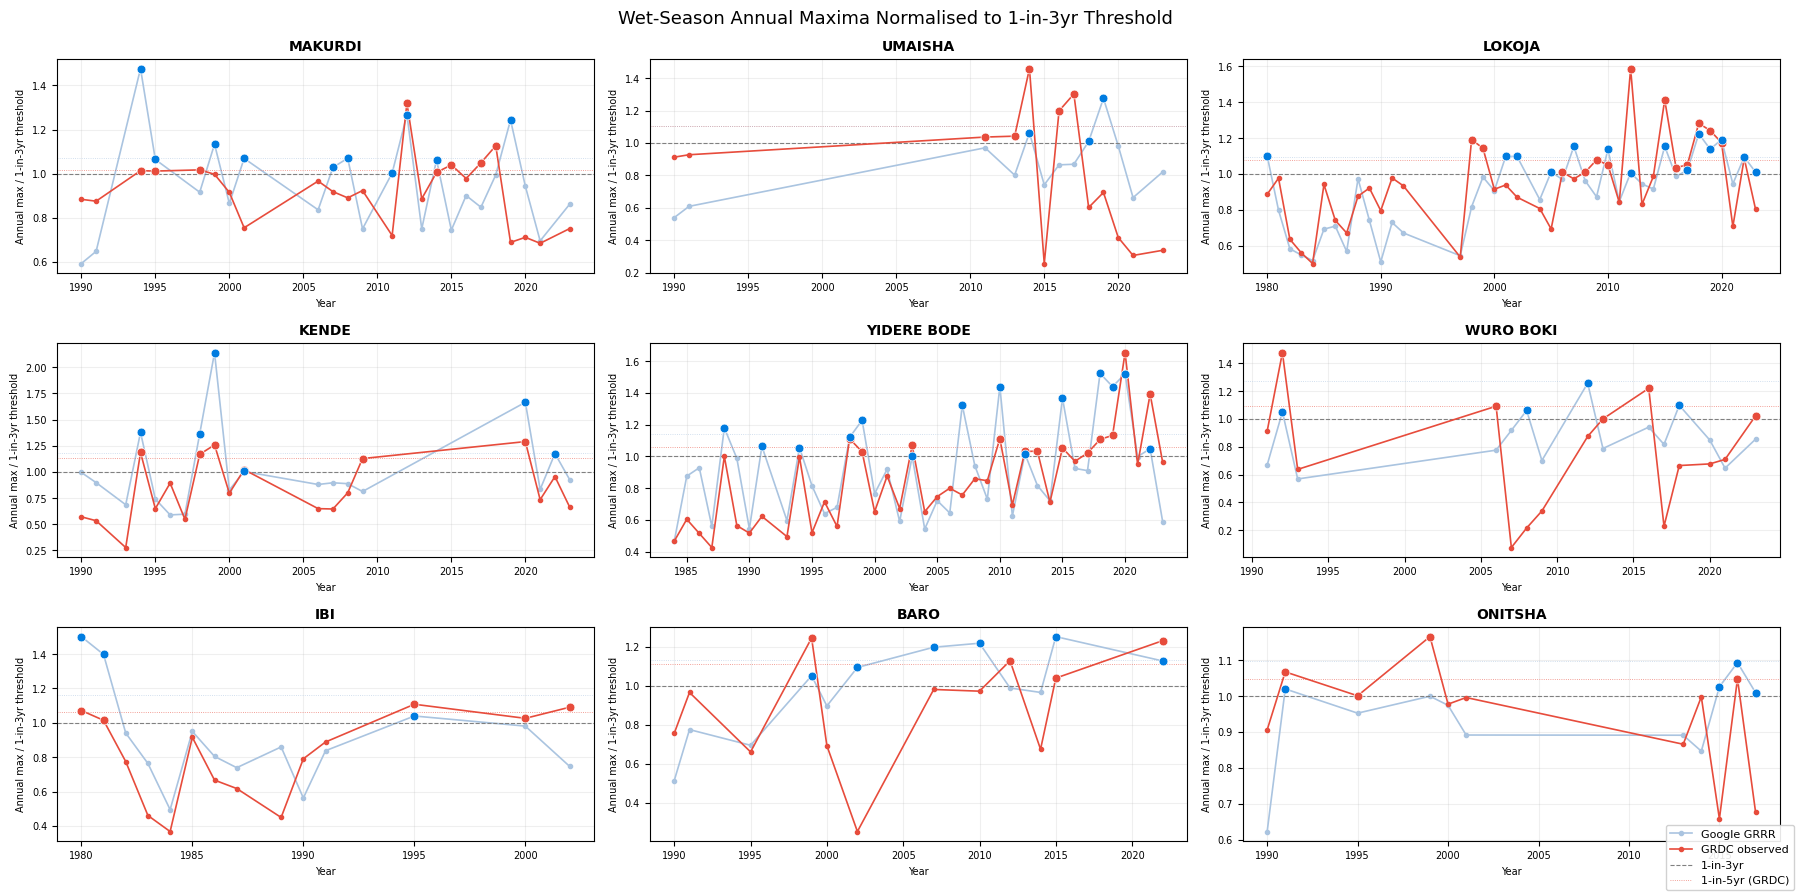

In [28]:
# Normalised annual maxima timelines — both datasets on the same scale (1.0 = 1-in-3yr threshold)
ordered_peak_ids = [gid for gid in gauge_mapping if gid in peak_data]
n_stations = len(ordered_peak_ids)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3 * nrows), sharex=False)
axes = axes.flatten()

for i, grdc_id in enumerate(ordered_peak_ids):
    ax = axes[i]
    d = peak_data[grdc_id]
    ann = d["ann"]

    ax.plot(ann["year"], ann["google_norm"], color="#aac4e0", linewidth=1.2,
            marker="o", markersize=3, label="Google GRRR", zorder=2)
    ax.plot(ann["year"], ann["grdc_norm"], color="#e74c3c", linewidth=1.2,
            marker="o", markersize=3, label="GRDC observed", zorder=3)

    # Threshold lines (1-in-3yr = 1.0 by construction; 1-in-5yr varies)
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", label="1-in-3yr")
    ax.axhline(d["grdc_5yr_norm"], color="#e74c3c", linewidth=0.6, linestyle=":",
               alpha=0.7, label="1-in-5yr (GRDC)")
    ax.axhline(d["google_5yr_norm"], color="#aac4e0", linewidth=0.6, linestyle=":",
               alpha=0.7, label="1-in-5yr (Google)")

    # Highlight years where GRDC exceeds 1-in-3yr
    exceed_grdc = ann[ann["grdc_exceed_3yr"]]
    ax.scatter(exceed_grdc["year"], exceed_grdc["grdc_norm"],
               color="#e74c3c", s=40, zorder=5, edgecolors="white", linewidths=0.5)

    # Highlight years where Google exceeds 1-in-3yr
    exceed_google = ann[ann["google_exceed_3yr"]]
    ax.scatter(exceed_google["year"], exceed_google["google_norm"],
               color="#007CE0", s=40, zorder=5, edgecolors="white", linewidths=0.5)

    ax.set_title(d["station"], fontsize=10, fontweight="bold")
    ax.set_ylabel("Annual max / 1-in-3yr threshold", fontsize=7)
    ax.set_xlabel("Year", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], loc="lower right", fontsize=8, framealpha=0.9)
fig.suptitle("Wet-Season Annual Maxima Normalised to 1-in-3yr Threshold", fontsize=13)
plt.tight_layout()
plt.show()

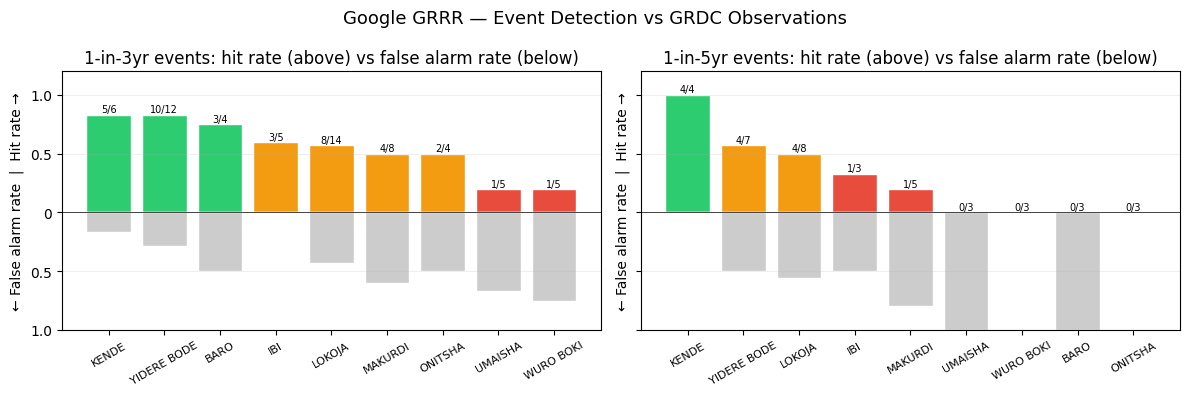

,station,rp,n_years,tp,fp,fn,tn,hit_rate,false_alarm_rate
0,MAKURDI,3,24,4,6,4,10,0.50,0.60
1,MAKURDI,5,24,1,4,4,15,0.20,0.80
2,UMAISHA,3,13,1,2,4,6,0.20,0.67
3,UMAISHA,5,13,0,1,3,9,0.00,1.00
4,LOKOJA,3,39,8,6,6,19,0.57,0.43
5,LOKOJA,5,39,4,5,4,26,0.50,0.56
6,KENDE,3,19,5,1,1,12,0.83,0.17
7,KENDE,5,19,4,0,0,15,1.00,0.00
8,YIDERE BODE,3,39,10,4,2,23,0.83,0.29
9,YIDERE BODE,5,39,4,4,3,28,0.57,0.50


In [29]:
# Event agreement summary: hit rate and false alarm rate for each station × return period
agreement_rows = []

for grdc_id, d in peak_data.items():
    ann = d["ann"]
    for rp in RETURN_PERIODS:
        grdc_exc = ann[f"grdc_exceed_{rp}yr"]
        google_exc = ann[f"google_exceed_{rp}yr"]
        n = len(ann)
        tp = (grdc_exc & google_exc).sum()   # both flag
        fp = (~grdc_exc & google_exc).sum()  # Google flags, GRDC doesn't
        fn = (grdc_exc & ~google_exc).sum()  # GRDC flags, Google doesn't
        tn = (~grdc_exc & ~google_exc).sum() # neither flags
        hit_rate = tp / grdc_exc.sum() if grdc_exc.sum() > 0 else np.nan
        far = fp / google_exc.sum() if google_exc.sum() > 0 else np.nan
        agreement_rows.append(dict(
            station=d["station"], rp=rp, n_years=n,
            tp=tp, fp=fp, fn=fn, tn=tn,
            hit_rate=round(hit_rate, 2), false_alarm_rate=round(far, 2),
        ))

df_agree = pd.DataFrame(agreement_rows)

# Plot: grouped bar chart of hit rate per station for each RP
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, rp in zip(axes, RETURN_PERIODS):
    sub = df_agree[df_agree["rp"] == rp].sort_values("hit_rate", ascending=False)
    colors = ["#2ecc71" if h >= 0.7 else "#f39c12" if h >= 0.4 else "#e74c3c"
              for h in sub["hit_rate"]]
    bars = ax.bar(sub["station"], sub["hit_rate"], color=colors, edgecolor="white")
    ax.bar(sub["station"], -sub["false_alarm_rate"], color="#cccccc", edgecolor="white",
           label="False alarm rate (Google flags, GRDC doesn't)")

    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{row.tp}/{row.tp + row.fn}", ha="center", fontsize=7)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylim(-1, 1.2)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(["1.0", "0.5", "0", "0.5", "1.0"])
    ax.set_ylabel("← False alarm rate  |  Hit rate →")
    ax.set_title(f"1-in-{rp}yr events: hit rate (above) vs false alarm rate (below)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Google GRRR — Event Detection vs GRDC Observations", fontsize=13)
plt.tight_layout()
plt.show()

df_agree[["station", "rp", "n_years", "tp", "fp", "fn", "tn", "hit_rate", "false_alarm_rate"]]